In [1]:
# 'pandas' lets us load and work with tabular data
import pandas as pd

# Load the iris dataset
df = pd.read_csv("1) iris.csv")

# Our usual "First Look" routine
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Shape: (150, 5)

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of duplicate rows: 3


In [2]:
# Remove exact duplicate rows, keeping the first occurrence of each
df = df.drop_duplicates()

# Confirm the new shape
print("Shape after removing duplicates:", df.shape)
print("Number of duplicate rows now:", df.duplicated().sum())

Shape after removing duplicates: (147, 5)
Number of duplicate rows now: 0


In [3]:
from sklearn.preprocessing import LabelEncoder

# Create the encoder
le = LabelEncoder()

# Encode species into numbers
df["species_encoded"] = le.fit_transform(df["species"])

# Let's see the mapping it created
print(df[["species", "species_encoded"]].drop_duplicates())

        species  species_encoded
0        setosa                0
50   versicolor                1
100   virginica                2


In [4]:
from sklearn.preprocessing import StandardScaler

# These are our genuine numeric feature columns
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

# Create the scaler
scaler = StandardScaler()

# Fit and transform the feature columns
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Let's check the result
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species  \
0     -0.915509     1.019971     -1.357737      -1.3357  setosa   
1     -1.157560    -0.128082     -1.357737      -1.3357  setosa   
2     -1.399610     0.331139     -1.414778      -1.3357  setosa   
3     -1.520635     0.101529     -1.300696      -1.3357  setosa   
4     -1.036535     1.249582     -1.357737      -1.3357  setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# X = our 4 measurement features
X = df[feature_cols]

# y = the target we want to predict (the encoded species)
y = df["species_encoded"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Model trained successfully!
Training set size: (117, 4)
Testing set size: (30, 4)


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Step 1: Ask the model to predict species for the TEST set
y_pred = log_model.predict(X_test)

# Step 2: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Step 3: Calculate precision and recall
# Since we have 3 categories (not just 2), we average across all of them
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
print("Precision:", precision)
print("Recall:", recall)

# Step 4: A full breakdown, category by category
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9666666666666667
Precision: 0.9666666666666667
Recall: 0.9666666666666667

Full classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.90      0.95        10
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



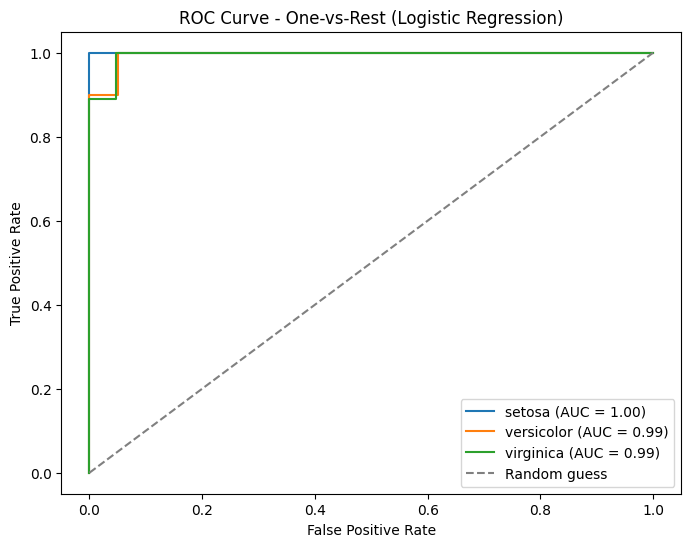

In [7]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Convert our 3-category answers into 3 separate "yes/no" columns
# (one column per species: "is it this species, or not?")
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Step 2: Get the model's predicted PROBABILITIES (not just final answers)
y_prob = log_model.predict_proba(X_test)

# Step 3: Plot one ROC curve per species
plt.figure(figsize=(8, 6))

for i, species_name in enumerate(le.classes_):
    fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{species_name} (AUC = {roc_auc:.2f})")

# Draw the "random guessing" reference line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-vs-Rest (Logistic Regression)")
plt.legend()
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Train SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Compare all 3 models
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 0.9666666666666667
Random Forest Accuracy: 0.9333333333333333
SVM Accuracy: 0.9333333333333333


C:\Users\USER-PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [9]:
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

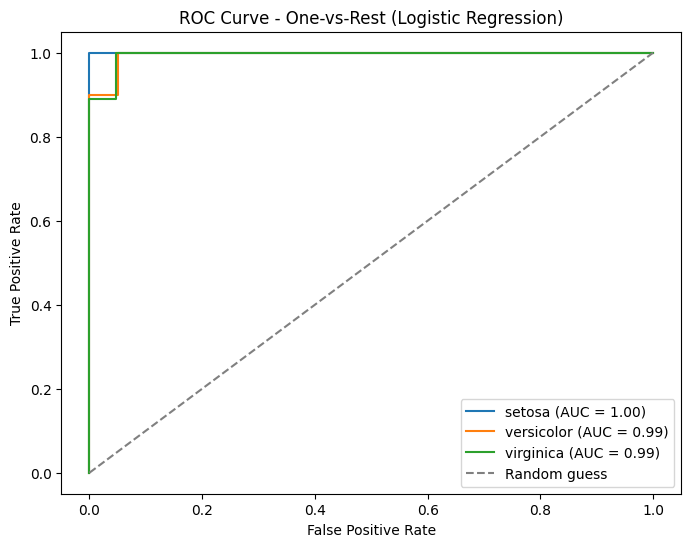

In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Convert our 3-category answers into 3 separate "yes/no" columns
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])

# Step 2: Get the model's predicted PROBABILITIES
y_prob = log_model.predict_proba(X_test)

# Step 3: Plot one ROC curve per species
plt.figure(figsize=(8, 6))

for i, species_name in enumerate(le.classes_):
    fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{species_name} (AUC = {roc_auc:.2f})")

# Draw the "random guessing" reference line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-vs-Rest (Logistic Regression)")
plt.legend()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()